## 3. Dataset Preparation

The LEVIR-CD dataset is used for training, validation, and testing.

The same dataset splits used for the FC-Siam-Conc baseline are retained
to ensure a consistent and fair comparison between the two models.

Since ChangeFormer is trained using 256 × 256 inputs, all input image
pairs are resized to 256 × 256 during preprocessing.

The binary change masks are resized using nearest-neighbor interpolation
to preserve their discrete class labels.

In [1]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", DEVICE)

Using: cuda


In [2]:
from pathlib import Path
from PIL import Image

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class ChangeFormerLEVIRDataset(Dataset):

    def __init__(self, root_dir):

        self.root_dir = Path(root_dir)

        self.a_images = sorted(
            (self.root_dir / "A").glob("*")
        )

        self.b_images = sorted(
            (self.root_dir / "B").glob("*")
        )

        self.labels = sorted(
            (self.root_dir / "label").glob("*")
        )

        self.image_transform = transforms.Compose([
            transforms.Resize(
                (256, 256)
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[
                    0.45026043,
                    0.44666810,
                    0.38134657
                ],
                std=[
                    0.19258917,
                    0.18164736,
                    0.16908678
                ]
            )
        ])

        self.mask_transform = transforms.Resize(
            (256, 256),
            interpolation=transforms.InterpolationMode.NEAREST
        )


    def __len__(self):
        return len(self.a_images)


    def __getitem__(self, index):

        before = Image.open(
            self.a_images[index]
        ).convert("RGB")

        after = Image.open(
            self.b_images[index]
        ).convert("RGB")

        mask = Image.open(
            self.labels[index]
        )

        before = self.image_transform(before)

        after = self.image_transform(after)

        mask = self.mask_transform(mask)

        mask = np.array(mask)

        mask = (mask > 0).astype(np.int64)

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return before, after, mask

In [3]:
import os

DATASET_PATH = "../data"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH   = os.path.join(DATASET_PATH, "val")
TEST_PATH  = os.path.join(DATASET_PATH, "test")

print("Train:", TRAIN_PATH)
print("Val  :", VAL_PATH)
print("Test :", TEST_PATH)

Train: ../data\train
Val  : ../data\val
Test : ../data\test


In [4]:
train_dataset = ChangeFormerLEVIRDataset(
    TRAIN_PATH
)

val_dataset = ChangeFormerLEVIRDataset(
    VAL_PATH
)

test_dataset = ChangeFormerLEVIRDataset(
    TEST_PATH
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 445
Validation samples: 64
Test samples: 128


In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 1
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [6]:
before, after, mask = next(iter(train_loader))

print("Before :", before.shape)
print("After  :", after.shape)
print("Mask   :", mask.shape)
print("Mask dtype:", mask.dtype)
print("Mask values:", torch.unique(mask))

Before : torch.Size([1, 3, 256, 256])
After  : torch.Size([1, 3, 256, 256])
Mask   : torch.Size([1, 256, 256])
Mask dtype: torch.int64
Mask values: tensor([0, 1])


In [7]:
import sys
from pathlib import Path

CHANGEFORMER_PATH = Path("../ChangeFormer").resolve()

if str(CHANGEFORMER_PATH) not in sys.path:
    sys.path.insert(0, str(CHANGEFORMER_PATH))

print("ChangeFormer path:", CHANGEFORMER_PATH)

from types import SimpleNamespace
from models.networks import define_G

args = SimpleNamespace(
    net_G="ChangeFormerV6",
    embed_dim=256,
    output_nc=2
)

model = define_G(
    args,
    gpu_ids=[]
)

model = model.to(DEVICE)

print("Model:", model.__class__.__name__)
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

ChangeFormer path: C:\Users\balas\capstone\ChangeFormer


C:\Users\balas\anaconda3\envs\myenv\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


initialize network with normal
Model: ChangeFormerV6
Trainable parameters: 41026674


In [8]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Loss, optimizer and scheduler initialized.")

Loss, optimizer and scheduler initialized.


In [9]:
import os

SAVE_DIR = "../saved_models/changeformer"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_model.pth"
)

LAST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "last_model.pth"
)

print("Best model :", BEST_MODEL_PATH)
print("Last model :", LAST_MODEL_PATH)

Best model : ../saved_models/changeformer\best_model.pth
Last model : ../saved_models/changeformer\last_model.pth


In [10]:
model.train()

before, after, mask = next(iter(train_loader))

before = before.to(DEVICE)
after = after.to(DEVICE)
mask = mask.to(DEVICE)

optimizer.zero_grad()

outputs = model(
    before,
    after
)

final_output = outputs[-1]

loss = criterion(
    final_output,
    mask
)

loss.backward()

optimizer.step()

print("Single training step successful!")
print("Output :", final_output.shape)
print("Mask   :", mask.shape)
print("Loss   :", loss.item())

Single training step successful!
Output : torch.Size([1, 2, 256, 256])
Mask   : torch.Size([1, 256, 256])
Loss   : 0.7534090280532837


In [11]:
import numpy as np
from tqdm.auto import tqdm


def calculate_metrics(outputs, targets):

    predictions = torch.argmax(outputs, dim=1)

    predictions = predictions.float()
    targets = targets.float()

    intersection = (predictions * targets).sum()
    union = predictions.sum() + targets.sum() - intersection

    iou = (
        (intersection + 1e-7) /
        (union + 1e-7)
    )

    dice = (
        (2 * intersection + 1e-7) /
        (predictions.sum() + targets.sum() + 1e-7)
    )

    tp = ((predictions == 1) & (targets == 1)).sum().float()
    fp = ((predictions == 1) & (targets == 0)).sum().float()
    fn = ((predictions == 0) & (targets == 1)).sum().float()

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-7)
    )

    return {
        "iou": iou.item(),
        "dice": dice.item(),
        "f1": f1.item()
    }

In [12]:
NUM_EPOCHS = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")


for epoch in range(NUM_EPOCHS):

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    train_loss = 0.0

    train_metrics = {
        "iou": 0.0,
        "dice": 0.0,
        "f1": 0.0
    }

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    for before, after, mask in train_bar:

        before = before.to(DEVICE)
        after = after.to(DEVICE)
        mask = mask.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(
            before,
            after
        )

        final_output = outputs[-1]

        loss = criterion(
            final_output,
            mask
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        metrics = calculate_metrics(
            final_output,
            mask
        )

        train_metrics["iou"] += metrics["iou"]
        train_metrics["dice"] += metrics["dice"]
        train_metrics["f1"] += metrics["f1"]

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader)

    train_losses.append(train_loss)

    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    val_loss = 0.0

    val_metrics = {
        "iou": 0.0,
        "dice": 0.0,
        "f1": 0.0
    }

    with torch.no_grad():

        for before, after, mask in val_loader:

            before = before.to(DEVICE)
            after = after.to(DEVICE)
            mask = mask.to(DEVICE)

            outputs = model(
                before,
                after
            )

            final_output = outputs[-1]

            loss = criterion(
                final_output,
                mask
            )

            val_loss += loss.item()

            metrics = calculate_metrics(
                final_output,
                mask
            )

            val_metrics["iou"] += metrics["iou"]
            val_metrics["dice"] += metrics["dice"]
            val_metrics["f1"] += metrics["f1"]

    val_loss /= len(val_loader)

    val_losses.append(val_loss)

    # ==========================================
    # AVERAGE METRICS
    # ==========================================

    train_iou = (
        train_metrics["iou"] /
        len(train_loader)
    )

    train_dice = (
        train_metrics["dice"] /
        len(train_loader)
    )

    train_f1 = (
        train_metrics["f1"] /
        len(train_loader)
    )

    val_iou = (
        val_metrics["iou"] /
        len(val_loader)
    )

    val_dice = (
        val_metrics["dice"] /
        len(val_loader)
    )

    val_f1 = (
        val_metrics["f1"] /
        len(val_loader)
    )

    # ==========================================
    # LEARNING RATE SCHEDULER
    # ==========================================

    scheduler.step(val_loss)

    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        best_status = " ⭐ BEST"

    else:

        best_status = ""

    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print()
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}{best_status}")
    print("=" * 60)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print(f"Train F1   : {train_f1:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

Epoch 1/30:   0%|          | 0/445 [00:00<?, ?it/s]


Epoch 1/30 ⭐ BEST
Train Loss : 0.1474
Val Loss   : 0.1329
Train IoU  : 0.1164
Val IoU    : 0.2246
Train Dice : 0.1761
Val Dice   : 0.2882
Train F1   : 0.1581
Val F1     : 0.1788


Epoch 2/30:   0%|          | 0/445 [00:00<?, ?it/s]


Epoch 2/30
Train Loss : 0.1042
Val Loss   : 0.1427
Train IoU  : 0.2459
Val IoU    : 0.2400
Train Dice : 0.3574
Val Dice   : 0.3148
Train F1   : 0.3529
Val F1     : 0.2054


Epoch 3/30:   0%|          | 0/445 [00:00<?, ?it/s]

...


Epoch 28/30
Train Loss : 0.0113
Val Loss   : 0.1634
Train IoU  : 0.9125
Val IoU    : 0.4913
Train Dice : 0.9536
Val Dice   : 0.5985
Train F1   : 0.8480
Val F1     : 0.5047


Epoch 29/30:   0%|          | 0/445 [00:00<?, ?it/s]


Epoch 29/30
Train Loss : 0.0110
Val Loss   : 0.1616
Train IoU  : 0.9144
Val IoU    : 0.4920
Train Dice : 0.9546
Val Dice   : 0.5985
Train F1   : 0.8490
Val F1     : 0.5047


Epoch 30/30:   0%|          | 0/445 [00:00<?, ?it/s]


Epoch 30/30
Train Loss : 0.0107
Val Loss   : 0.1675
Train IoU  : 0.9167
Val IoU    : 0.4922
Train Dice : 0.9559
Val Dice   : 0.5984
Train F1   : 0.8503
Val F1     : 0.5047


In [13]:
torch.save(
    model.state_dict(),
    LAST_MODEL_PATH
)

print("Last model saved:")
print(LAST_MODEL_PATH)

Last model saved:
../saved_models/changeformer\last_model.pth


In [14]:
 BEST_MODEL_PATH = "../saved_models/changeformer/best_model.pth"

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)
model.eval()

print("Best ChangeFormer model loaded.")

Best ChangeFormer model loaded.


In [15]:
import torch
from tqdm.auto import tqdm

test_loss = 0.0

total_correct = 0
total_pixels = 0

total_tp = 0
total_fp = 0
total_fn = 0
total_intersection = 0
total_union = 0

with torch.no_grad():

    test_bar = tqdm(
        test_loader,
        desc="Testing ChangeFormer"
    )

    for before, after, mask in test_bar:

        before = before.to(DEVICE)
        after = after.to(DEVICE)
        mask = mask.to(DEVICE)

        outputs = model(
            before,
            after
        )

        final_output = outputs[-1]

        loss = criterion(
            final_output,
            mask
        )

        test_loss += loss.item()

        predictions = torch.argmax(
            final_output,
            dim=1
        )

        # Accuracy
        total_correct += (
            predictions == mask
        ).sum().item()

        total_pixels += mask.numel()

        # Binary change class
        pred_change = predictions == 1
        true_change = mask == 1

        tp = (pred_change & true_change).sum().item()
        fp = (pred_change & ~true_change).sum().item()
        fn = (~pred_change & true_change).sum().item()

        intersection = tp
        union = tp + fp + fn

        total_tp += tp
        total_fp += fp
        total_fn += fn

        total_intersection += intersection
        total_union += union


test_loss /= len(test_loader)

accuracy = total_correct / total_pixels

precision = (
    total_tp /
    (total_tp + total_fp + 1e-7)
)

recall = (
    total_tp /
    (total_tp + total_fn + 1e-7)
)

f1 = (
    2 * precision * recall /
    (precision + recall + 1e-7)
)

iou = (
    total_intersection /
    (total_union + 1e-7)
)

dice = (
    2 * total_intersection /
    (
        2 * total_intersection
        + total_fp
        + total_fn
        + 1e-7
    )
)

print()
print("=" * 60)
print("ChangeFormer — TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {accuracy:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test F1        : {f1:.4f}")
print(f"Test IoU       : {iou:.4f}")
print(f"Test Dice      : {dice:.4f}")

print("=" * 60)

Testing ChangeFormer:   0%|          | 0/128 [00:00<?, ?it/s]


ChangeFormer — TEST SET RESULTS
Test Loss      : 0.0705
Test Accuracy  : 0.9760
Test Precision : 0.8196
Test Recall    : 0.6777
Test F1        : 0.7419
Test IoU       : 0.5897
Test Dice      : 0.7419


In [20]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\balas\capstone


In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from src.models.fc_siam_conc import FCSiamConc
# -------------------------------
# Load FC-Siam-Conc
# -------------------------------

fc_model = FCSiamConc().to(DEVICE)

fc_model.load_state_dict(
    torch.load(
         "../saved_models/fc_siam_conc/best_model.pth",
        map_location=DEVICE
    )
)

fc_model.eval()


# -------------------------------
# ChangeFormer is already loaded
# -------------------------------

changeformer_model = model
changeformer_model.eval()

print("Both models loaded successfully.")

Both models loaded successfully.


In [22]:
before, after, mask = test_dataset[0]

before_input = before.unsqueeze(0).to(DEVICE)
after_input = after.unsqueeze(0).to(DEVICE)

mask_np = mask.numpy()

with torch.no_grad():

    # FC-Siam-Conc
    fc_output = fc_model(
        before_input,
        after_input
    )

    fc_prediction = (
        torch.sigmoid(fc_output) > 0.5
    ).float()

    # ChangeFormer
    cf_outputs = changeformer_model(
        before_input,
        after_input
    )

    cf_output = cf_outputs[-1]

    cf_prediction = torch.argmax(
        cf_output,
        dim=1
    )

fc_prediction = (
    fc_prediction.squeeze()
    .cpu()
    .numpy()
)

cf_prediction = (
    cf_prediction.squeeze()
    .cpu()
    .numpy()
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [24]:
before_np = before.permute(1, 2, 0).cpu().numpy()
after_np = after.permute(1, 2, 0).cpu().numpy()

# Undo normalization for visualization
mean = np.array([
    0.45026043,
    0.44666810,
    0.38134657
])

std = np.array([
    0.19258917,
    0.18164736,
    0.16908678
])

before_np = before_np * std + mean
after_np = after_np * std + mean

before_np = np.clip(before_np, 0, 1)
after_np = np.clip(after_np, 0, 1)

In [26]:
import os

os.makedirs(
    "../results",
    exist_ok=True
)

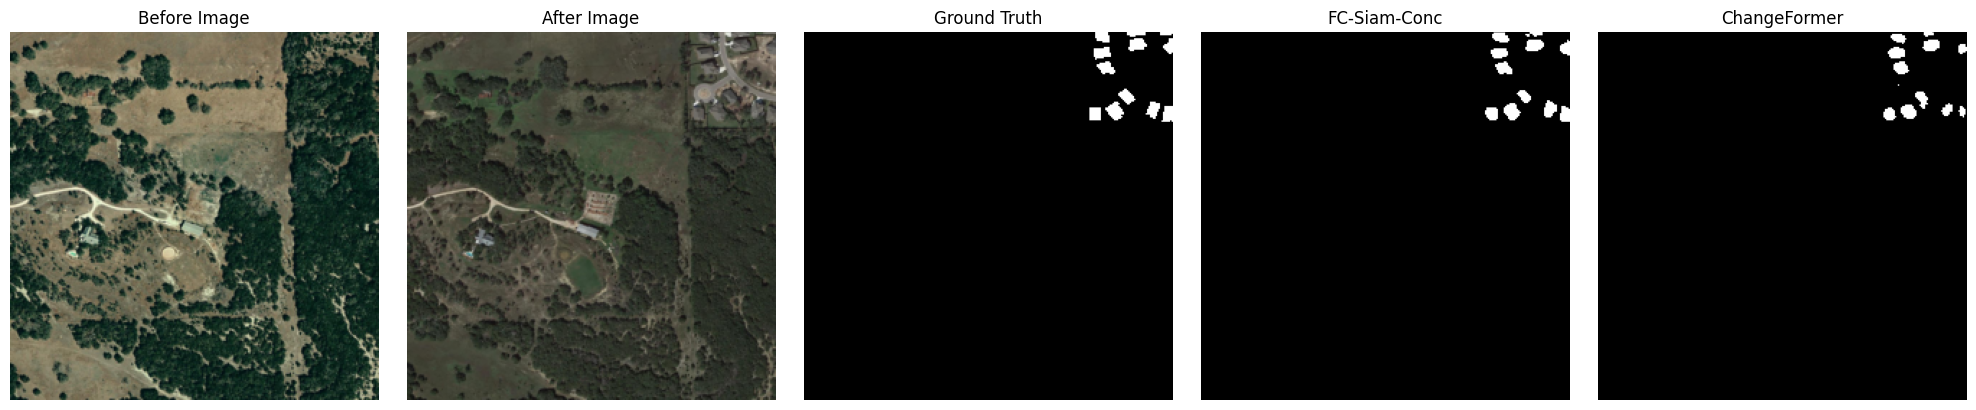

In [27]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4)
)

axes[0].imshow(before_np)
axes[0].set_title("Before Image")
axes[0].axis("off")

axes[1].imshow(after_np)
axes[1].set_title("After Image")
axes[1].axis("off")

axes[2].imshow(mask_np, cmap="gray")
axes[2].set_title("Ground Truth")
axes[2].axis("off")

axes[3].imshow(fc_prediction, cmap="gray")
axes[3].set_title("FC-Siam-Conc")
axes[3].axis("off")

axes[4].imshow(cf_prediction, cmap="gray")
axes[4].set_title("ChangeFormer")
axes[4].axis("off")

plt.tight_layout()

plt.savefig(
    "../results/model_comparison_sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusion

The ChangeFormer model was successfully implemented and trained for binary change detection on the LEVIR-CD dataset. The complete experimental pipeline included dataset preparation, 256 × 256 image preprocessing, ChangeFormerV6 model initialization, GPU-based training, validation, checkpoint selection, and independent test-set evaluation.

The trained ChangeFormer model achieved a **test IoU of 0.5897, Dice/F1 score of 0.7419, precision of 0.8196, and recall of 0.6777**, with an overall pixel accuracy of 0.9760. These results demonstrate that ChangeFormer is capable of learning meaningful spatial changes between bi-temporal satellite images.

When compared with the implemented FC-Siam-Conc baseline, FC-Siam-Conc achieved a higher **test IoU of 0.6940** and **Dice/F1 score of 0.8008** under the current experimental configuration. Therefore, FC-Siam-Conc demonstrated stronger binary change-detection performance in our experiment. This shows that a more complex transformer-based architecture does not necessarily outperform a well-designed convolutional Siamese architecture under identical experimental conditions.

Overall, the experiment establishes **ChangeFormer as a valid deep-learning approach for satellite image change detection** and provides a useful benchmark for further experimentation. Future improvements can focus on data augmentation, class-imbalance handling, hyperparameter optimization, preprocessing strategies, and architectural modifications.

## Final Experimental Comparison

| Model | Test IoU | Test Dice/F1 |
|---|---:|---:|
| FC-Siam-Conc | **0.6940** | **0.8008** |
| ChangeFormer | 0.5897 | 0.7419 |

## Key Finding

**Under the current experimental configuration, FC-Siam-Conc performed better than ChangeFormer for binary change detection on the LEVIR-CD test set.**